# Data Loading & Cleaning

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("train.csv")

print(df.shape)

df.head()

(913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.reset_index(
    drop=True,
    inplace=True
)

In [4]:
print(df.info())

print()

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB
None

                                date          store           item  \
count                         913000  913000.000000  913000.000000   
mean   2015-07-02 12:00:00.000000256       5.500000      25.500000   
min              2013-01-01 00:00:00       1.000000       1.000000   
25%              2014-04-02 00:00:00       3.000000      13.000000   
50%              2015-07-02 12:00:00       5.500000      25.500000   
75%              2016-10-01 00:00:00       8.000000      38.000000   
max              2017-12-31 00:00:00      10.000000      50.000000

In [5]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [6]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["month_name"] = (
    df["date"]
    .dt
    .month_name()
)

df["quarter"] = (
    df["date"]
    .dt
    .quarter
)

df["day_of_week"] = (
    df["date"]
    .dt
    .day_name()
)

# KPIs

In [7]:
total_sales = (
    df["sales"]
    .sum()
)

avg_daily_sales = (
    df["sales"]
    .mean()
)

stores = (
    df["store"]
    .nunique()
)

items = (
    df["item"]
    .nunique()
)

date_range = (
    df["date"].max() -
    df["date"].min()
).days

kpis = pd.DataFrame({

    "Metric":[
        "Total Units Sold",
        "Average Daily Sales",
        "Stores",
        "Items",
        "Days Covered"
    ],

    "Value":[
        f"{total_sales:,.0f}",
        f"{avg_daily_sales:.2f}",
        stores,
        items,
        date_range
    ]
})

kpis

,Metric,Value
0,Total Units Sold,"47,704,512"
1,Average Daily Sales,52.25
2,Stores,10
3,Items,50
4,Days Covered,1825


# EDA

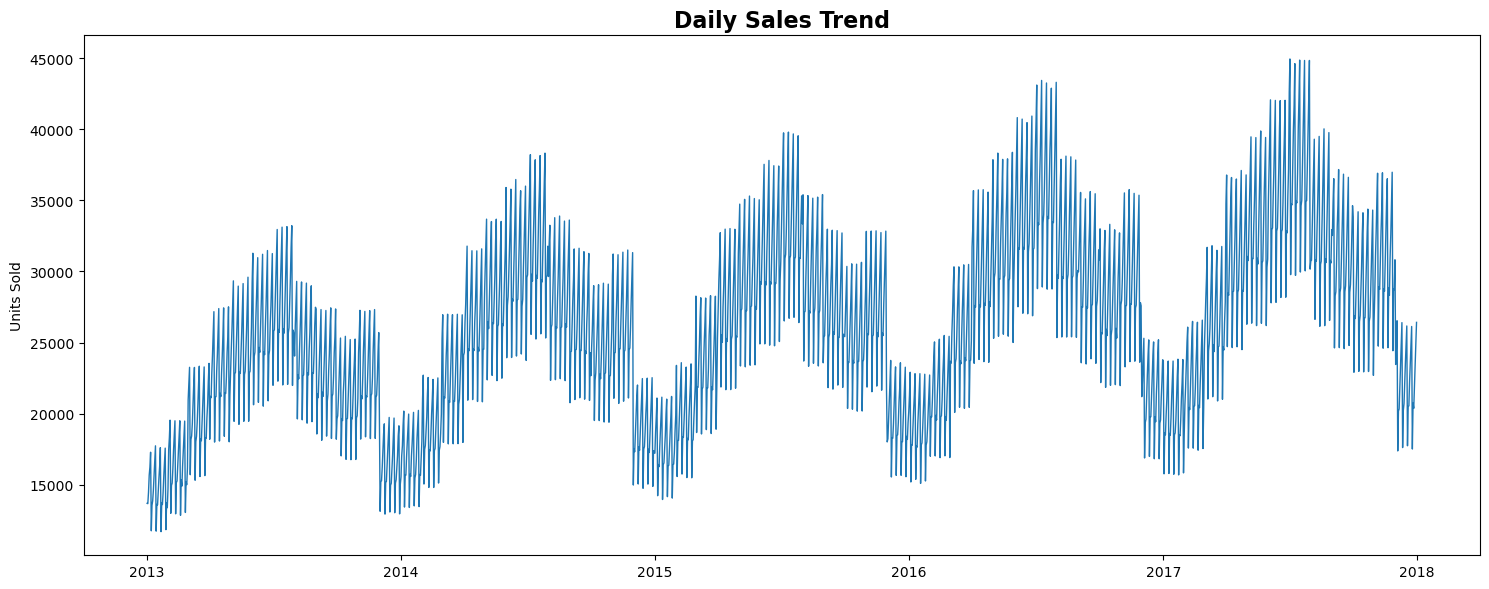

In [8]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
)

plt.figure(
    figsize=(15,6)
)

plt.plot(
    daily_sales.index,
    daily_sales.values,
    linewidth=1
)

plt.title(
    "Daily Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")

plt.ylabel(
    "Units Sold"
)

plt.tight_layout()

plt.show()

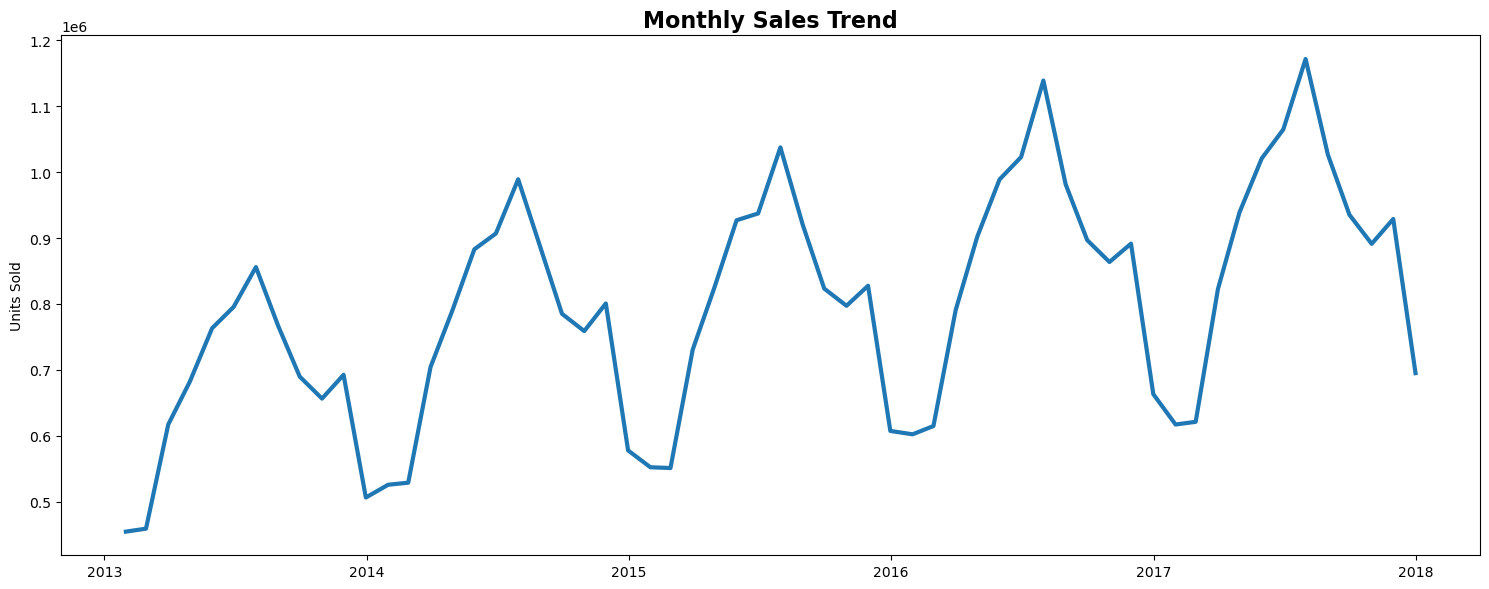

In [9]:
monthly_sales = (
    df
    .groupby(
        pd.Grouper(
            key="date",
            freq="M"
        )
    )["sales"]
    .sum()
)

plt.figure(
    figsize=(15,6)
)

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    linewidth=3
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")

plt.ylabel(
    "Units Sold"
)

plt.tight_layout()

plt.show()

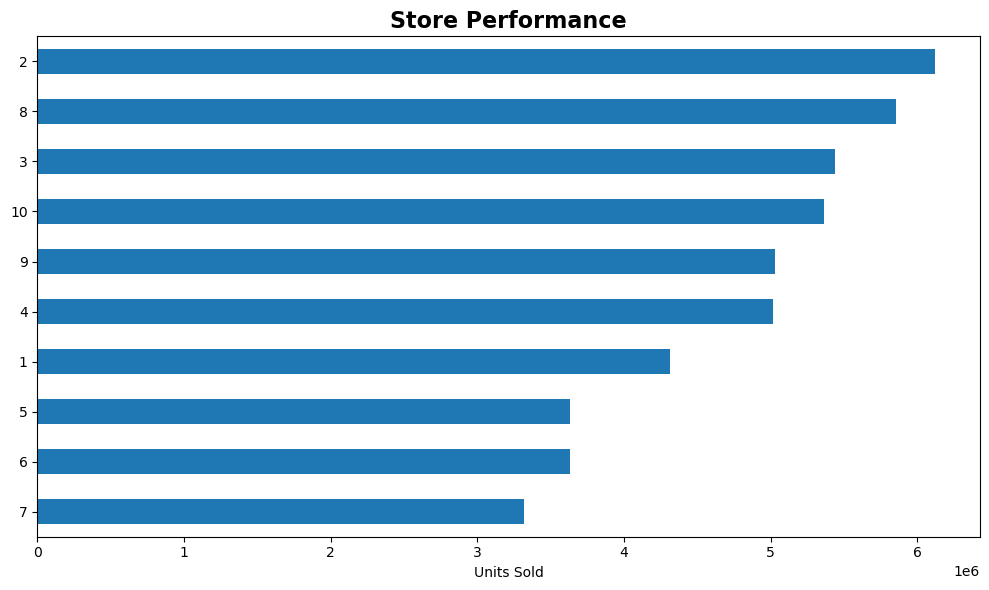

In [10]:
store_sales = (
    df.groupby("store")["sales"]
    .sum()
    .sort_values()
)

plt.figure(
    figsize=(10,6)
)

store_sales.plot(
    kind="barh"
)

plt.title(
    "Store Performance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Units Sold"
)

plt.ylabel("")

plt.tight_layout()

plt.show()

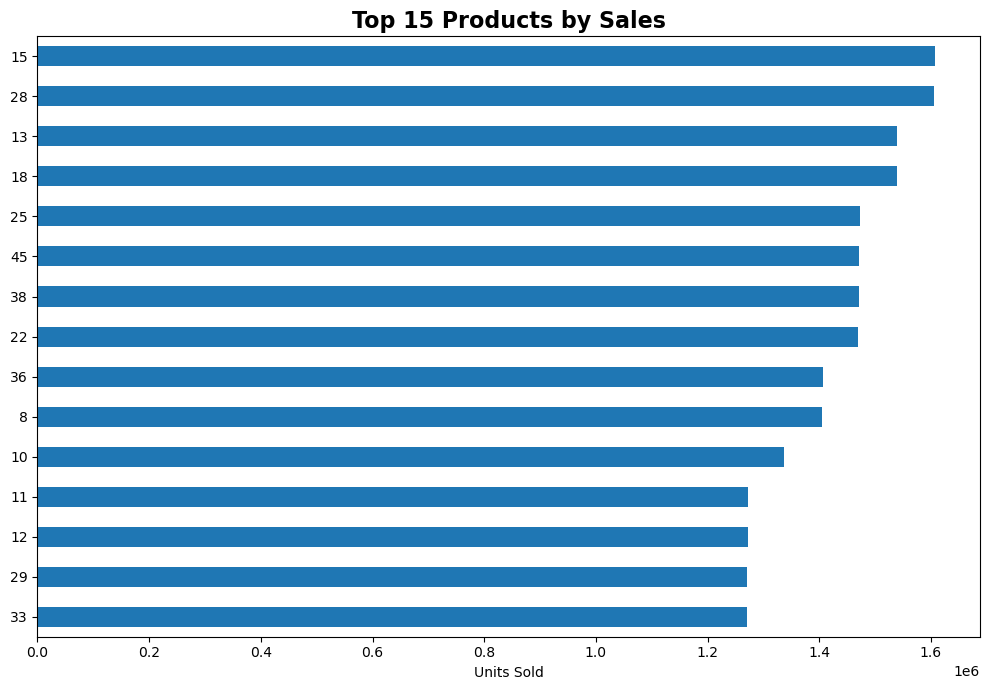

In [11]:
top_products = (
    df.groupby("item")["sales"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

plt.figure(
    figsize=(10,7)
)

top_products.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Products by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Units Sold"
)

plt.ylabel("")

plt.tight_layout()

plt.show()

# Forecasting Model

In [12]:
daily_demand = (
    df.groupby("date")["sales"]
    .sum()
    .reset_index()
)

daily_demand.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


In [13]:
train_size = int(len(daily_demand) * 0.8)

train = daily_demand.iloc[:train_size]
test = daily_demand.iloc[train_size:]

print(train.shape)
print(test.shape)

(1460, 2)
(366, 2)


In [14]:
from prophet import Prophet

In [15]:
prophet_df = train.rename(
    columns={
        "date": "ds",
        "sales": "y"
    }
)

In [16]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(prophet_df)

20:52:55 - cmdstanpy - INFO - Chain [1] start processing
20:52:55 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
future = model.make_future_dataframe(
    periods=len(test)
)

forecast = model.predict(future)

In [18]:
predictions = forecast.tail(len(test))

mae = mean_absolute_error(
    test["sales"],
    predictions["yhat"]
)

mape = mean_absolute_percentage_error(
    test["sales"],
    predictions["yhat"]
)

r2 = r2_score(
    test["sales"],
    predictions["yhat"]
)

print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape*100:.2f}%")
print(f"R²: {r2:.3f}")

MAE: 1486.77
MAPE: 5.62%
R²: 0.925


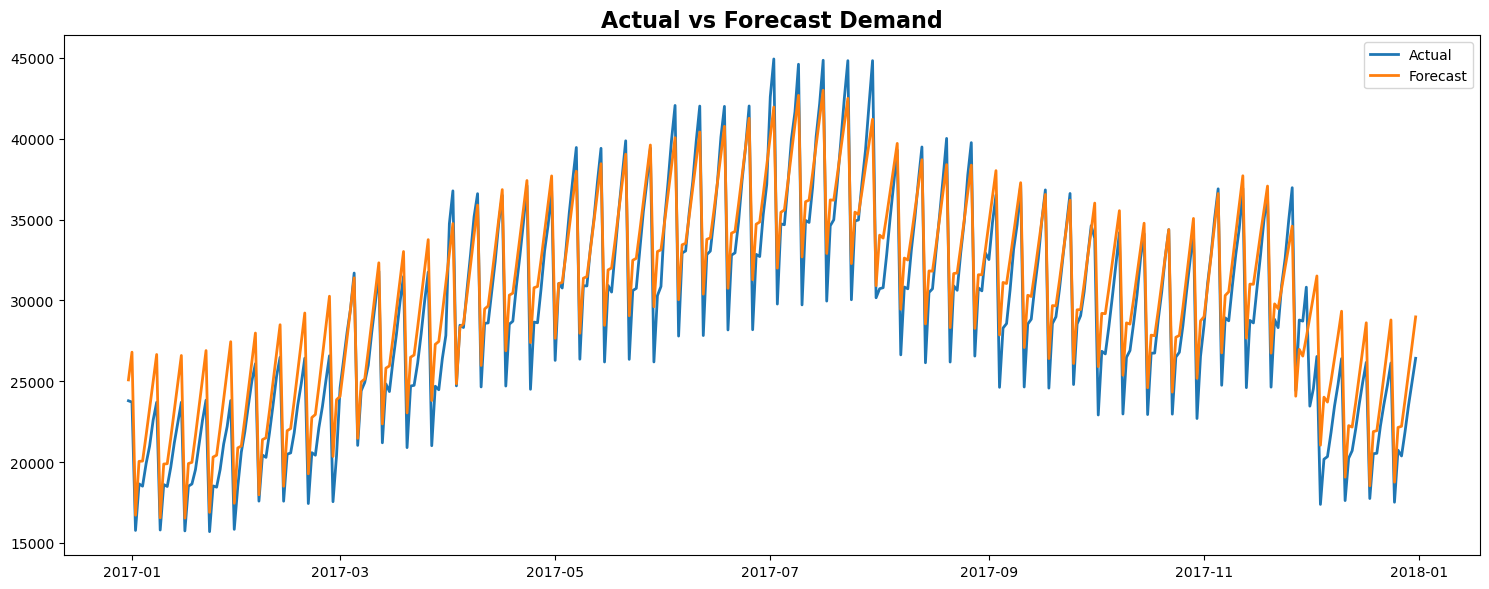

In [19]:
plt.figure(figsize=(15,6))

plt.plot(
    test["date"],
    test["sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test["date"],
    predictions["yhat"],
    label="Forecast",
    linewidth=2
)

plt.title(
    "Actual vs Forecast Demand",
    fontsize=16,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()

plt.show()

In [20]:
future_90 = model.make_future_dataframe(
    periods=90
)

forecast_90 = model.predict(
    future_90
)

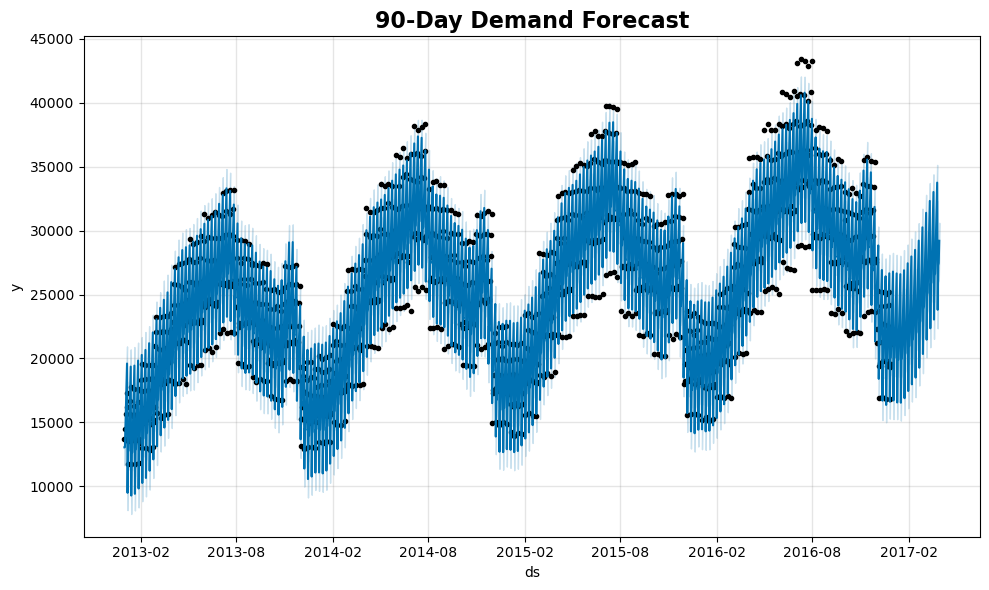

In [21]:
fig = model.plot(forecast_90)

plt.title(
    "90-Day Demand Forecast",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Inventory Planning

In [22]:
forecast_demand = (
    forecast_90["yhat"]
    .tail(90)
    .mean()
)

In [23]:
average_daily_demand = forecast_demand

lead_time = 7

service_factor = 1.65

In [24]:
demand_std = (
    daily_demand["sales"]
    .std()
)

In [25]:
safety_stock = (
    service_factor *
    demand_std *
    np.sqrt(lead_time)
)

In [27]:
reorder_point = (
    average_daily_demand *
    lead_time
    +
    safety_stock
)

In [28]:
inventory_kpis = pd.DataFrame({

    "Metric":[
        "Average Daily Demand",
        "Safety Stock",
        "Reorder Point"
    ],

    "Value":[
        round(average_daily_demand),
        round(safety_stock),
        round(reorder_point)
    ]
})

inventory_kpis

,Metric,Value
0,Average Daily Demand,24582
1,Safety Stock,28019
2,Reorder Point,200095


In [29]:
inventory_position = []

for demand in forecast_90["yhat"].tail(30):

    if demand >= average_daily_demand * 1.2:
        inventory_position.append("High Risk")

    elif demand >= average_daily_demand:
        inventory_position.append("Medium Risk")

    else:
        inventory_position.append("Low Risk")

risk_df = pd.DataFrame({
    "Date": forecast_90["ds"].tail(30),
    "Forecast Demand": forecast_90["yhat"].tail(30).values,
    "Risk": inventory_position
})

risk_df.head()

,Date,Forecast Demand,Risk
1520,2017-03-01,24062.544887,Low Risk
1521,2017-03-02,25831.585597,Medium Risk
1522,2017-03-03,27702.847027,Medium Risk
1523,2017-03-04,29524.814874,High Risk
1524,2017-03-05,31396.844979,High Risk


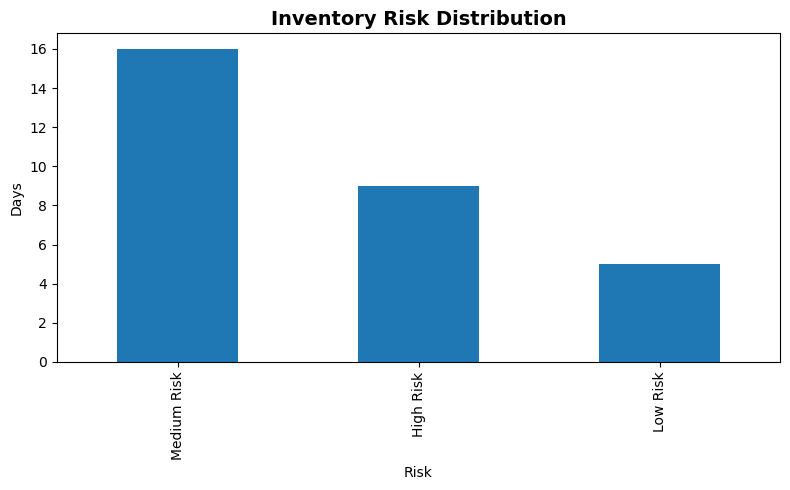

In [30]:
risk_counts = (
    risk_df["Risk"]
    .value_counts()
)

plt.figure(figsize=(8,5))

risk_counts.plot(
    kind="bar"
)

plt.title(
    "Inventory Risk Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Days")

plt.tight_layout()

plt.show()

In [31]:
recommendations = pd.DataFrame({

    "Area":[
        "Demand Forecasting",
        "Inventory Planning",
        "Stock Optimization",
        "Supply Chain"
    ],

    "Recommendation":[
        "Maintain forecast updates weekly",
        f"Reorder inventory below {round(reorder_point):,}",
        f"Keep safety stock near {round(safety_stock):,}",
        "Monitor high demand periods closely"
    ]
})

recommendations

,Area,Recommendation
0,Demand Forecasting,Maintain forecast updates weekly
1,Inventory Planning,"Reorder inventory below 200,095"
2,Stock Optimization,"Keep safety stock near 28,019"
3,Supply Chain,Monitor high demand periods closely


In [32]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

# =========================
# TABLES
# =========================

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Average Daily Sales",
        "Stores",
        "Items",
        "Days Covered"
    ],
    "Value": [
        total_sales,
        round(avg_daily_sales, 2),
        stores,
        items,
        date_range
    ]
})

forecast_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MAPE (%)",
        "R² Score"
    ],
    "Value": [
        round(mae, 2),
        round(mape * 100, 2),
        round(r2, 3)
    ]
})

inventory_planning = pd.DataFrame({
    "Metric": [
        "Average Daily Demand",
        "Safety Stock",
        "Reorder Point"
    ],
    "Value": [
        round(average_daily_demand),
        round(safety_stock),
        round(reorder_point)
    ]
})

recommendations = pd.DataFrame({
    "Area": [
        "Demand Forecasting",
        "Inventory Planning",
        "Stock Optimization",
        "Supply Chain"
    ],
    "Recommendation": [
        "Update forecasts weekly",
        f"Reorder inventory below {round(reorder_point):,}",
        f"Maintain safety stock near {round(safety_stock):,}",
        "Monitor demand spikes and seasonality"
    ]
})

# =========================
# EXPORT
# =========================

output_file = "Demand_Forecasting_Inventory_Planning_Report.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    executive_summary.to_excel(
        writer,
        sheet_name="Executive Summary",
        index=False
    )

    forecast_metrics.to_excel(
        writer,
        sheet_name="Forecast Metrics",
        index=False
    )

    inventory_planning.to_excel(
        writer,
        sheet_name="Inventory Planning",
        index=False
    )

    recommendations.to_excel(
        writer,
        sheet_name="Recommendations",
        index=False
    )

# =========================
# FORMAT WORKBOOK
# =========================

wb = load_workbook(output_file)

header_fill = PatternFill(
    start_color="1F4E78",
    end_color="1F4E78",
    fill_type="solid"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

for ws in wb.worksheets:

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font

    for col in ws.columns:

        max_length = 0
        column = col[0].column

        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass

        adjusted_width = max_length + 4

        ws.column_dimensions[
            get_column_letter(column)
        ].width = adjusted_width

wb.save(output_file)

print(f"Workbook created: {output_file}")

Workbook created: Demand_Forecasting_Inventory_Planning_Report.xlsx


In [33]:
pip install reportlab

Note: you may need to restart the kernel to use updated packages.


In [34]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak,
    Image
)

from reportlab.lib.styles import getSampleStyleSheet

pdf_file = "Demand_Forecasting_Report.pdf"

doc = SimpleDocTemplate(pdf_file)

styles = getSampleStyleSheet()

elements = []

In [44]:
elements.append(
    Paragraph(
        "Demand Forecasting & Inventory Planning Report",
        styles["Title"]
    )
)

elements.append(
    Spacer(1,20)
)

elements.append(
    Paragraph(
        "Prepared using Python, Pandas and Prophet",
        styles["Normal"]
    )
)

elements.append(
    PageBreak()
)

In [45]:
elements.append(
    Paragraph(
        "Executive Summary",
        styles["Heading1"]
    )
)

summary_text = f"""
The business recorded total sales of
<b>{total_sales:,.0f}</b> units across
<b>{stores}</b> stores and
<b>{items}</b> products.

The forecasting model achieved
<b>MAPE of {mape*100:.2f}%</b>
and
<b>R² of {r2:.3f}</b>,
indicating strong predictive accuracy.

The recommended reorder point is
<b>{round(reorder_point):,}</b>
units with a safety stock of
<b>{round(safety_stock):,}</b> units.
"""

elements.append(
    Paragraph(
        summary_text,
        styles["BodyText"]
    )
)

elements.append(
    Spacer(1,20)
)

In [46]:
elements.append(
    Paragraph(
        "Executive Summary",
        styles["Heading1"]
    )
)

summary_text = f"""
The business recorded total sales of
<b>{total_sales:,.0f}</b> units across
<b>{stores}</b> stores and
<b>{items}</b> products.

The forecasting model achieved
<b>MAPE of {mape*100:.2f}%</b>
and
<b>R² of {r2:.3f}</b>,
indicating strong predictive accuracy.

The recommended reorder point is
<b>{round(reorder_point):,}</b>
units with a safety stock of
<b>{round(safety_stock):,}</b> units.
"""

elements.append(
    Paragraph(
        summary_text,
        styles["BodyText"]
    )
)

elements.append(
    Spacer(1,20)
)

In [47]:
elements.append(
    Paragraph(
        "Business KPIs",
        styles["Heading1"]
    )
)

kpi_text = f"""
Total Units Sold: {total_sales:,.0f}<br/>
Average Daily Sales: {avg_daily_sales:.2f}<br/>
Stores: {stores}<br/>
Items: {items}<br/>
Days Covered: {date_range}
"""

elements.append(
    Paragraph(
        kpi_text,
        styles["BodyText"]
    )
)

elements.append(
    Spacer(1,20)
)

In [48]:
elements.append(
    Paragraph(
        "Sales Trend Analysis",
        styles["Heading1"]
    )
)

elements.append(
    Image(
        "monthly_sales_trend.png",
        width=450,
        height=250
    )
)

elements.append(
    Spacer(1,20)
)

In [49]:
elements.append(
    PageBreak()
)

elements.append(
    Paragraph(
        "Forecasting Results",
        styles["Heading1"]
    )
)

forecast_text = f"""
MAE: {mae:.2f}<br/>
MAPE: {mape*100:.2f}%<br/>
R² Score: {r2:.3f}
"""

elements.append(
    Paragraph(
        forecast_text,
        styles["BodyText"]
    )
)

In [50]:
elements.append(
    Paragraph(
        "Inventory Planning",
        styles["Heading1"]
    )
)

inventory_text = f"""
Average Daily Demand:
{round(average_daily_demand):,}<br/>

Safety Stock:
{round(safety_stock):,}<br/>

Reorder Point:
{round(reorder_point):,}
"""

elements.append(
    Paragraph(
        inventory_text,
        styles["BodyText"]
    )
)

In [51]:
elements.append(
    Paragraph(
        "Recommendations",
        styles["Heading1"]
    )
)

recommendation_text = """
• Update forecasts weekly.<br/>
• Monitor high demand periods.<br/>
• Maintain recommended safety stock levels.<br/>
• Reorder inventory before reaching the calculated reorder point.<br/>
• Use forecast outputs to optimize purchasing decisions.
"""

elements.append(
    Paragraph(
        recommendation_text,
        styles["BodyText"]
    )
)

In [52]:
doc.build(elements)

print(
    "Demand_Forecasting_Report.pdf created successfully."
)

Demand_Forecasting_Report.pdf created successfully.
